<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Stability001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipython-input-366412576.py:49: RuntimeWarning: invalid value encountered in log
  S = -phi * np.log(phi + epsilon)
/tmp/ipython-input-366412576.py:103: RuntimeWarning: invalid value encountered in log
  S = -phi * np.log(phi + 1e-10)
/tmp/ipython-input-366412576.py:33: RuntimeWarning: invalid value encountered in log
  S = -phi * np.log(phi + epsilon)


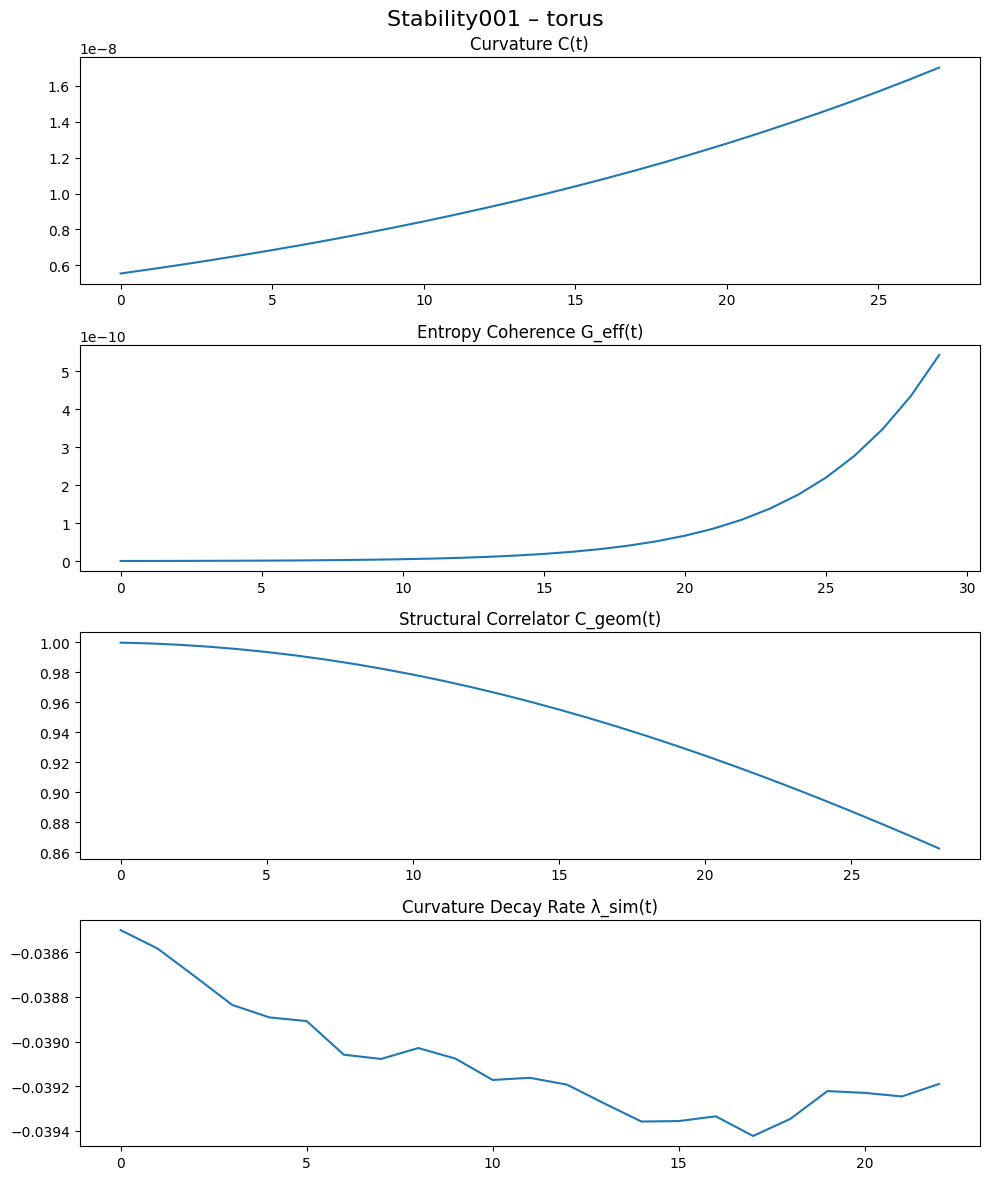

In [ ]:
# Stability001: Toroidal Attractor Simulation Harness
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Module 1: Initialize Field
# -----------------------------
def initialize_field(config_type, L):
    x, y = np.meshgrid(np.linspace(-1, 1, L), np.linspace(-1, 1, L))
    r = np.sqrt(x**2 + y**2)

    if config_type == "torus":
        phi = np.exp(-((r - 0.5)**2) * 100)
    elif config_type == "sphere":
        phi = np.exp(-(r**2) * 100)
    elif config_type == "noise":
        phi = np.random.rand(L, L)
    else:
        raise ValueError("Unknown configuration type")

    return phi / np.sum(phi)

# -----------------------------
# Module 2: Update Field
# -----------------------------
def update_field(phi, alpha, beta, gamma, delta, L):
    grad_phi_x = (np.roll(phi, -1, axis=0) - np.roll(phi, 1, axis=0)) / 2
    grad_phi_y = (np.roll(phi, -1, axis=1) - np.roll(phi, 1, axis=1)) / 2
    grad_phi = grad_phi_x + grad_phi_y

    phi_mean = np.mean(phi)
    epsilon = 1e-10
    S = -phi * np.log(phi + epsilon)

    laplacian_S = (
        -4 * S +
        np.roll(S, 1, axis=0) + np.roll(S, -1, axis=0) +
        np.roll(S, 1, axis=1) + np.roll(S, -1, axis=1)
    ) / (L ** 2)

    phi_new = phi - alpha * grad_phi + beta * phi + gamma * phi_mean * phi + delta * laplacian_S
    return phi_new

# -----------------------------
# Module 3: Compute Curvature
# -----------------------------
def compute_curvature(phi, L):
    epsilon = 1e-10
    S = -phi * np.log(phi + epsilon)

    laplacian_S = (
        -4 * S +
        np.roll(S, 1, axis=0) + np.roll(S, -1, axis=0) +
        np.roll(S, 1, axis=1) + np.roll(S, -1, axis=1)
    ) / (L ** 2)

    curvature = np.abs(laplacian_S)
    return np.mean(curvature)

# -----------------------------
# Module 4: Compute λ_sim
# -----------------------------
def compute_lambda_sim(C_series, delta_t=5):
    lambda_sim = []
    for t in range(len(C_series) - delta_t):
        ratio = C_series[t + delta_t] / (C_series[t] + 1e-10)
        lambda_t = -np.log(ratio) / delta_t
        lambda_sim.append(lambda_t)
    return lambda_sim

# -----------------------------
# Module 5: Compute G_eff
# -----------------------------
def compute_G_eff(S):
    grad_x = np.abs(S[1:-1, -1] - S[1:-1, -2])  # right edge
    grad_y = np.abs(S[-1, 1:-1] - S[-2, 1:-1])  # bottom edge
    boundary_grad = np.concatenate([grad_x, grad_y])
    return np.mean(boundary_grad)

# -----------------------------
# Module 6: Compute C_geom
# -----------------------------
def compute_C_geom(phi_0, phi_t):
    phi_0_norm = phi_0 / (np.linalg.norm(phi_0) + 1e-10)
    phi_t_norm = phi_t / (np.linalg.norm(phi_t) + 1e-10)
    return np.sum(phi_0_norm * phi_t_norm)

# -----------------------------
# Module 7: Run Simulation
# -----------------------------
def run_simulation(config_type, alpha, beta, gamma, delta, L, T_max):
    phi = initialize_field(config_type, L)
    phi_0 = np.copy(phi)

    C_series = []
    G_eff_series = []
    C_geom_series = []

    for t in range(T_max):
        phi = update_field(phi, alpha, beta, gamma, delta, L)
        C_series.append(compute_curvature(phi, L))

        S = -phi * np.log(phi + 1e-10)
        G_eff_series.append(compute_G_eff(S))
        C_geom_series.append(compute_C_geom(phi_0, phi))

    lambda_sim_series = compute_lambda_sim(C_series)
    return C_series, G_eff_series, C_geom_series, lambda_sim_series

# -----------------------------
# Module 8: Plot Results
# -----------------------------
def plot_results(C_series, G_eff_series, C_geom_series, lambda_sim_series, title):
    fig, axs = plt.subplots(4, 1, figsize=(10, 12))
    axs[0].plot(C_series); axs[0].set_title("Curvature C(t)")
    axs[1].plot(G_eff_series); axs[1].set_title("Entropy Coherence G_eff(t)")
    axs[2].plot(C_geom_series); axs[2].set_title("Structural Correlator C_geom(t)")
    axs[3].plot(lambda_sim_series); axs[3].set_title("Curvature Decay Rate λ_sim(t)")
    fig.suptitle(f"Stability001 – {title}", fontsize=16)
    plt.tight_layout()
    plt.show()

# -----------------------------
# Run Stability001
# -----------------------------
# Parameters
config_type = "torus"  # Options: "torus", "sphere", "noise"
alpha = 0.1
beta = 0.05
gamma = 0.02
delta = 0.1
L = 100
T_max = 100

# Run and plot
C_series, G_eff_series, C_geom_series, lambda_sim_series = run_simulation(
    config_type, alpha, beta, gamma, delta, L, T_max
)
plot_results(C_series, G_eff_series, C_geom_series, lambda_sim_series, config_type)
